## 3. Import Libraries and Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure,
distribution and relationships within the dataset.

In [4]:
# Display first 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Separate features and target
X = housing.data
y = housing.target

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (20640, 8)
Target shape: (20640,)


In [5]:
# Check dataset information
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [6]:
# Statistical summary
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


### 4.1 Missing Value Analysis

In [7]:
# Check for missing values
print("Missing values in each feature:")
print(X.isnull().sum())

Missing values in each feature:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


### 4.2 Target Variable Distribution

In [8]:
# View target values
print(y.head())

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [9]:
# Statistical summary of house prices
print(y.describe())

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


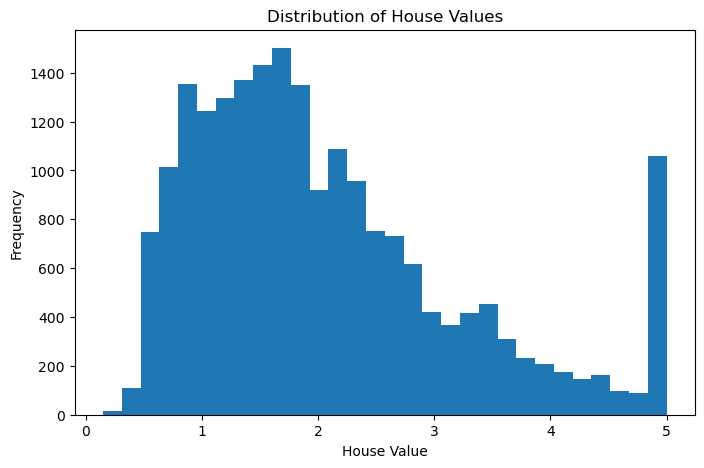

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=30)

plt.xlabel("House Value")
plt.ylabel("Frequency")
plt.title("Distribution of House Values")

plt.show()

### 4.3 Correlation Analysis

In [11]:
# Create correlation matrix
correlation = housing.frame.corr()

# Display correlation with house value
print(correlation["MedHouseVal"].sort_values(ascending=False))

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


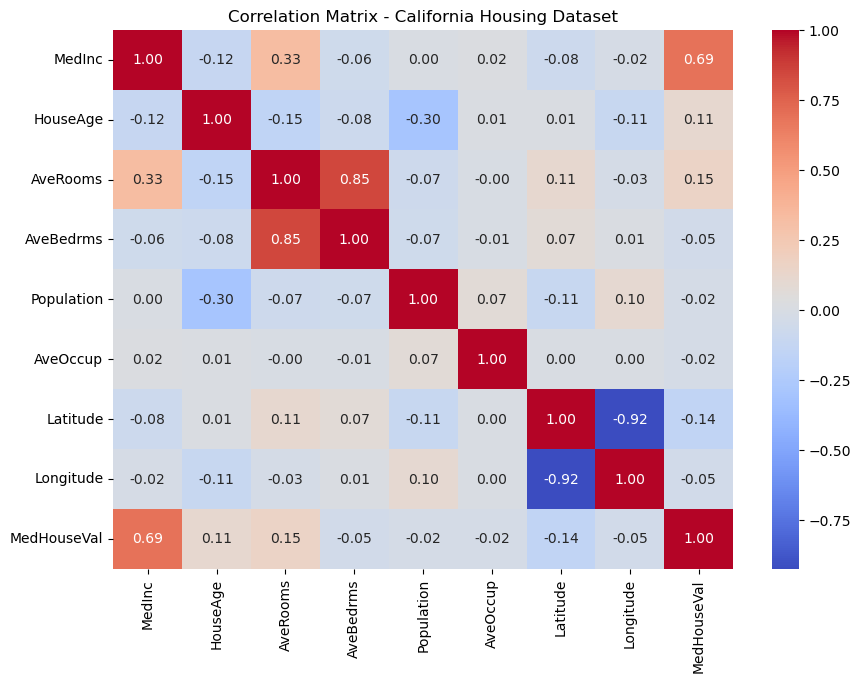

In [12]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - California Housing Dataset")
plt.show()

In [13]:
plt.savefig("correlation_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [14]:
from sklearn.model_selection import train_test_split

## 5. Train-Test Split

In [15]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)


In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
# Create Linear Regression model
model = LinearRegression()

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


## 6. Model Training

A Linear Regression model is trained using the training dataset.

In [18]:
# Train the model using training data
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [19]:
# Predict house values using the test data
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [20]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## 8. Model Evaluation

The trained model is evaluated using Mean Absolute Error (MAE),
Root Mean Squared Error (RMSE), and R² Score.

In [22]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 0.5332001304956556
RMSE: 0.7455813830127763
R²  : 0.575787706032451


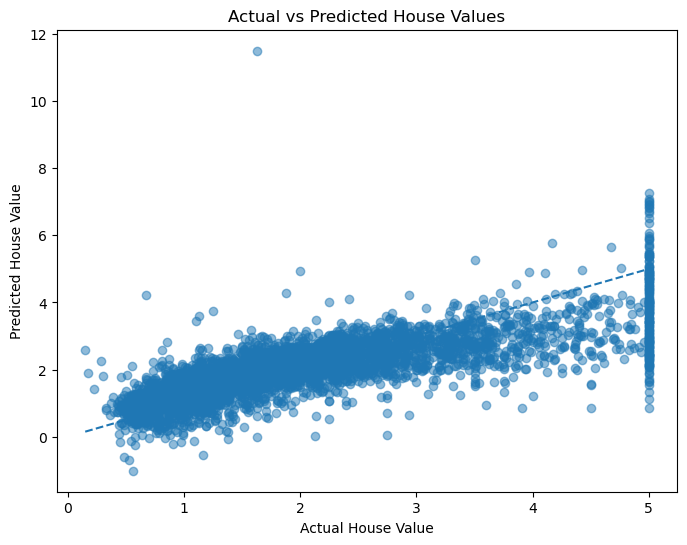

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## 9. Actual vs Predicted Values

In [24]:
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

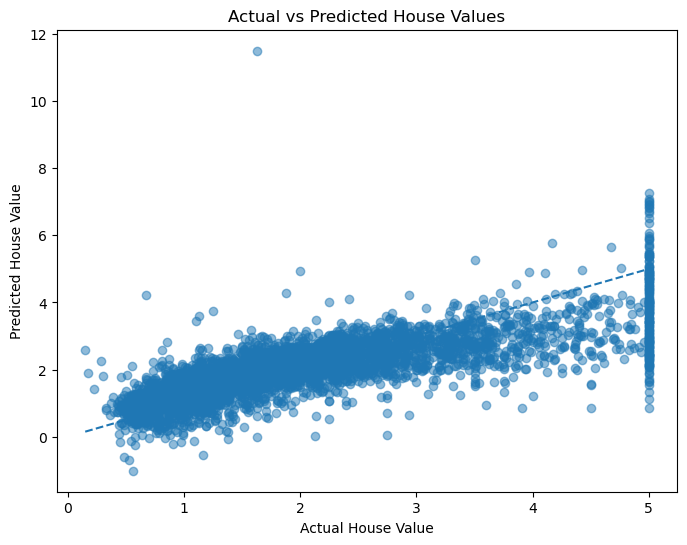

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()

In [27]:
# Calculate residuals
residuals = y_test - y_pred

print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
20046   -0.242123
3024    -1.306017
15663    2.290351
20484   -0.652926
9814     0.175343
13311   -0.424754
7113    -0.663500
7668    -0.593755
18246    0.659254
5723     0.550385
Name: MedHouseVal, dtype: float64


## 10. Residual Analysis

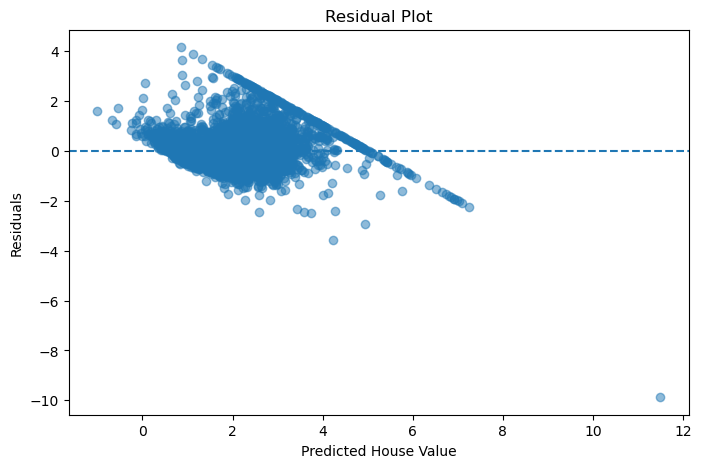

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## 11. Model Coefficients

In [29]:
# Display model coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [30]:
print("Model Intercept:", model.intercept_)

Model Intercept: -37.02327770606408


### Model Coefficients

The Linear Regression model learns a coefficient for each input feature.
These coefficients represent the direction and magnitude of the linear
relationship between the features and the target variable, while the
intercept represents the constant term of the regression equation.

## Model Improvement Ideas

The performance of the Linear Regression model can potentially be improved by:

1. **Feature Engineering**  
   Create additional meaningful features from the existing variables.

2. **Feature Scaling**  
   Standardize numerical features when using models that are sensitive to feature scale.

3. **Try Non-Linear Models**  
   Models such as Random Forest, Gradient Boosting, or other tree-based methods can capture non-linear relationships.

4. **Hyperparameter Tuning**  
   For models that have tunable parameters, use cross-validation and hyperparameter search to find better configurations.

5. **Outlier Analysis**  
   Identify and investigate unusual observations that may affect model performance.

6. **Cross-Validation**  
   Use k-fold cross-validation to obtain a more reliable estimate of model performance.

7. **Larger or Additional Data**  
   Additional relevant housing and geographic information may help improve predictions.

# Build & Evaluate a Linear Regression Model
## California Housing Price Predictor

**Internship:** Artificial Intelligence & Machine Learning – Task 1  
**Organization:** MainCrafts Technology  
**Author:** Somya Jain  

---

## 1. Objective

The objective of this project is to build and evaluate a Linear Regression
model for predicting house values using the California Housing dataset.

The project covers the complete machine learning workflow:

- Data loading
- Data exploration
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Train-test splitting
- Linear Regression model training
- Prediction
- Model evaluation using MAE, RMSE and R²
- Visualization of results
- Model improvement ideas

## 2. Dataset

The California Housing dataset provided by scikit-learn is used for this
project.

The dataset contains information about housing districts in California.
It includes 20,640 samples and 8 input features.

The target variable is `MedHouseVal`, which represents the median house
value for each district.

## 13. Conclusion

In this project, a Linear Regression model was developed to predict
California house values using the California Housing dataset.

The complete machine learning workflow was implemented, including data
exploration, preprocessing, train-test splitting, model training,
prediction, evaluation and visualization.

The model was evaluated using MAE, RMSE and R² Score. The results provide
a baseline for house value prediction. Further improvements can be
explored using feature engineering, cross-validation and non-linear
machine learning models.

In [33]:
import pickle

In [34]:
# Save the trained model
with open("linear_regression_house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [35]:
# Create a summary table of model performance

results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [mae, rmse, r2]
})

results

,Metric,Value
0,MAE,0.533200
1,RMSE,0.745581
2,R² Score,0.575788


In [36]:
# Show a few actual vs predicted values

final_comparison = pd.DataFrame({
    "Actual House Value": y_test.iloc[:10].values,
    "Predicted House Value": y_pred[:10]
})

final_comparison

,Actual House Value,Predicted House Value
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [37]:
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [39]:
import pickle

# Save the trained Linear Regression model
with open("linear_regression_house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
